Competition link - https://unearthed.solutions/u/competitions/94/data

In [14]:
import pandas as pd
import numpy as np

# plotting
import matplotlib.pyplot as plt
%matplotlib inline

# settings
plt.style.use('seaborn')
plt.rcParams["figure.figsize"] = (15, 5)

# Data Exploration

**About the data -**

* Alarm data from January 2020 through to October 2020 for specific process plant areas
* Targets for prediction, which are the top 10 category 2 alarms over the next 30 days generated from each timestamp that a new alarm appears
The alarm data contains the following fields:

**Field Description -**
* **timestamp** - the date and time an alarm event occurs
* **category** - the "importance" of the alarm. category 1 alarms represent significant failure events whilst category 4 events are more informational in nature. OZ Minerals would like to predict category 2 alarms, so that they can react before events cause significant failures
* **tag** - the unique name of the alarm recorded in the source system
* **description** - a description of what the alarm means (this is a more human readable form of the tag)
* **alarm1 through alarm10** - the targets to predict, each field represents the unique tag of the top 10 alarms by frequency that occur in the next 30 days from the timestamp of the "current" alarm. alarm1 contains the most frequent tag in the next 30 days, alarm2 contains the second most frequent, and so on through to the tenth most frequent alarm


In [46]:
df = pd.read_csv('../../datasets/sound-the-alarm/data/public/public.csv.gz')

In [47]:
df.shape

(35905, 14)

In [48]:
df.sort_values(by='timestamp').head()

,timestamp,category,tag,description,alarm1,alarm2,alarm3,alarm4,alarm5,alarm6,alarm7,alarm8,alarm9,alarm10
0,2020-01-01 01:24:46,2,PDI31163_AH,Crusher PPD003 Lube Oil Filter Differential Pr...,PDI31163_AH,PSH31055_Alarm,FI31134_AL,FI31133_AL,PDSH32106A_Alarm,FI31132_AL,PDSH32106B_Alarm,_3110_FAN_086_LOS,_3110_PPD_060_LOS,TI31012C_AH
1,2020-01-01 01:33:05,4,PDI31163_AHH,Crusher PPD003 Lube Oil Filter Differential Pr...,PDI31163_AH,PSH31055_Alarm,FI31134_AL,FI31133_AL,PDSH32106A_Alarm,FI31132_AL,PDSH32106B_Alarm,_3110_FAN_086_LOS,_3110_PPD_060_LOS,TI31012C_AH
2,2020-01-01 01:45:39,4,FI34140_AH,Cleaner 4 Dilution Water Flow High,PDI31163_AH,PSH31055_Alarm,FI31134_AL,FI31133_AL,PDSH32106A_Alarm,FI31132_AL,PDSH32106B_Alarm,_3110_FAN_086_LOS,_3110_PPD_060_LOS,TI31012C_AH
3,2020-01-01 01:46:18,4,FI34140_AHH,Cleaner 4 Dilution Water Flow High High,PDI31163_AH,PSH31055_Alarm,FI31134_AL,FI31133_AL,PDSH32106A_Alarm,FI31132_AL,PDSH32106B_Alarm,_3110_FAN_086_LOS,_3110_PPD_060_LOS,TI31012C_AH
4,2020-01-01 02:18:27,4,LI31122_AH,Primary Crusher Lube Oil Level High,PDI31163_AH,PSH31055_Alarm,FI31134_AL,FI31133_AL,PDSH32106A_Alarm,FI31132_AL,PDSH32106B_Alarm,_3110_FAN_086_LOS,_3110_PPD_060_LOS,TI31012C_AH


In [49]:
# check for missing values
df.isnull().sum()

timestamp      0
category       0
tag            0
description    0
alarm1         0
alarm2         0
alarm3         0
alarm4         0
alarm5         0
alarm6         0
alarm7         0
alarm8         0
alarm9         0
alarm10        0
dtype: int64

In [50]:
# convert int type to str as it is categorical
df['category'] = df['category'].apply(lambda x: str(x))

df.describe()

,timestamp,category,tag,description,alarm1,alarm2,alarm3,alarm4,alarm5,alarm6,alarm7,alarm8,alarm9,alarm10
count,35905,35905,35905,35905,35905,35905,35905,35905,35905,35905,35905,35905,35905,35905
unique,26428,3,621,568,11,14,23,31,30,34,43,48,51,55
top,2020-02-04 15:20:42,4,JI32152_AH,SAG Mill Motor 2 Power High,_3110_FAN_086_LOS,_3110_PPD_060_LOS,PI34136_AL,TI31013A_AL,PI34137_AL,PI31147_AL,TI31012B_AL,TI31012C_AL,TI31012A_AL,TI31012A_AL
freq,63,31095,1687,1687,16707,16839,11084,3632,6395,5604,3785,4963,7603,4642


# Data Exploration

#### 1. Number of alarms per day

In [51]:
# create date column
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['dt'] = df['timestamp'].dt.date

<AxesSubplot:>

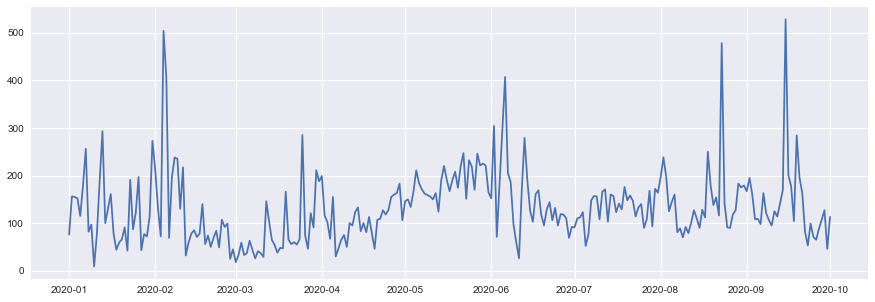

In [25]:
df['dt'].value_counts().plot()

Looks more than just random noise

In [26]:
# average number of alarms per day
df['dt'].value_counts().mean()

131.5201465201465

#### 2. Alarms by category per day

In [103]:
# create pivot table with dates as rows and alarm category as column
df_cat = df[['dt','category']].pivot_table(index='dt',columns='category',aggfunc=len)

<AxesSubplot:xlabel='dt'>

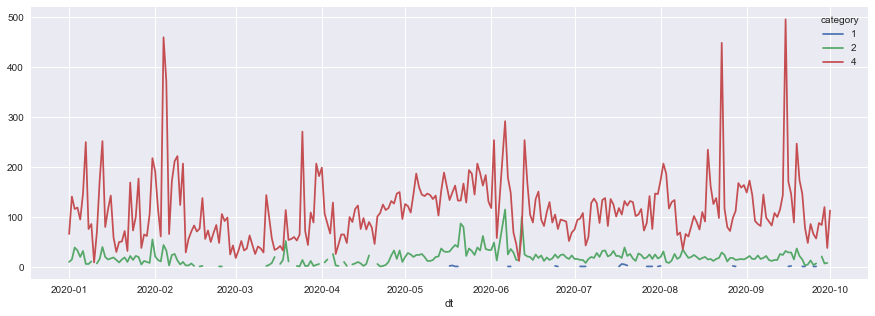

In [105]:
df_cat.plot()

1. Alarm category 1 are thankfully very few (usually 1 or 2), or none at all
2. Understandably the most frequent alarms are category 4, followed by 2 and then 1

#### 3. Alarm category in the top 10 alarm columns

We'll compare check if alarms in top 10 alarm columns indeed overlap with the category 2 alarms in column `tag`

In [113]:
alarm_col = ['alarm'+str(i) for i in range(1,11)]

cat2_alarms = df[df['category']=='2']['tag'].unique()
pred_alarms = df[alarm_col].unstack().unique()

In [115]:
intersect = set(cat2_alarms) & set(pred_alarms)
diff = set(cat2_alarms) - set(pred_alarms)

In [120]:
print (len(cat2_alarms),len(pred_alarms))
print (len(intersect),len(diff))

91 59
59 32


Indeed, the alarms in top 10 are all category 2. But there are certain category 2 alarms, 32 to be precise, that never show in top 10 - because they do not occur frequently enough to be in top 10